## Boosting


Algoritmos basado en arboles de decisiones
tenicas de ensemble learning o aprendizaje en conjunto  (en vez de usar un solo modelo, usan varios modelos juntos para mejorar los resultados)


Boosting-> Entrena modelos secuenciales donde cada modelo aprende del anterior
Boosting → modelos que aprenden de errores → se corrigen

Bagging -> Entrena modelos independientes en paralelo con diferentes muestras de datos y promediar los resultados
Bagging → muchos modelos independientes → promedian

---------------------------------------------------------------------
Algoritmos que emplea el boosting:Adaboost, Gradient Boosting, XGBoost, LightGBM, CatBoost
En boosting se utiliza un único algoritmo (como AdaBoost o XGBoost..etc), el cual entrena múltiples modelos débiles de forma secuencial, donde cada modelo corrige los errores del anterior.

Cuando decides usar Boosting, ocurre esto:

✔ eliges un algoritmo de boosting (AdaBoost, Gradient Boosting, XGBoost, LightGBM o CatBoost)
✔ ese algoritmo define cómo se construyen los modelos secuenciales y cómo se corrigen los errores
✔ luego ajustas sus hiperparámetros específicos

Cada algoritmo define: Cómo aprende de los errores
1. AdaBoost → ajusta pesos de datos
2. Gradient Boosting → usa gradiente de la función de error
3. XGBoost → mejora Gradient Boosting con optimización + regularización
4. LightGBM → optimización de estructura del árbol (leaf-wise)
5. CatBoost → manejo inteligente de variables categóricas

Dentro de un algoritmo de boosting tú eliges:

* número de iteraciones (n_estimators)
* profundidad de árboles
* learning rate

👉 Eso define cuántos “modelos secuenciales” se crean
Boosting reduce el sesgo y significa hacer que el modelo se acerque más a los valores reales, corrigiendo errores sistemáticos mediante aprendizaje secuencial.


Bagging: genera multiples subconjuntos aleatorios de datos, y entrena modelos de forma paralela para convinar sus predicciones 
usa algoritmos como random forest y arboles de decision o knn. generalmente y mayoritariamente random forest.

El Bagging es util para reducir la varianza,osea que tanto cambia el modelo si cambian un poco los datos de entrenamiento
Algunos modelos (como árboles de decisión):

aprenden demasiado los datos
cambian mucho si cambias el dataset

👉 son modelos de alta varianza
Bagging hace esto:

Entrena muchos modelos con datos distintos
Cada modelo se equivoca de forma diferente
Promedia los resultados consiguiendo que se “cancelen” las variaciones

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
# 1. Carga de datos
df = pd.read_csv('wine_data.csv')
df

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Clase
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,3
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,3
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,3
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
 13  Clase                 178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [5]:
df['Clase'].unique() #multiclase

array([1, 2, 3])

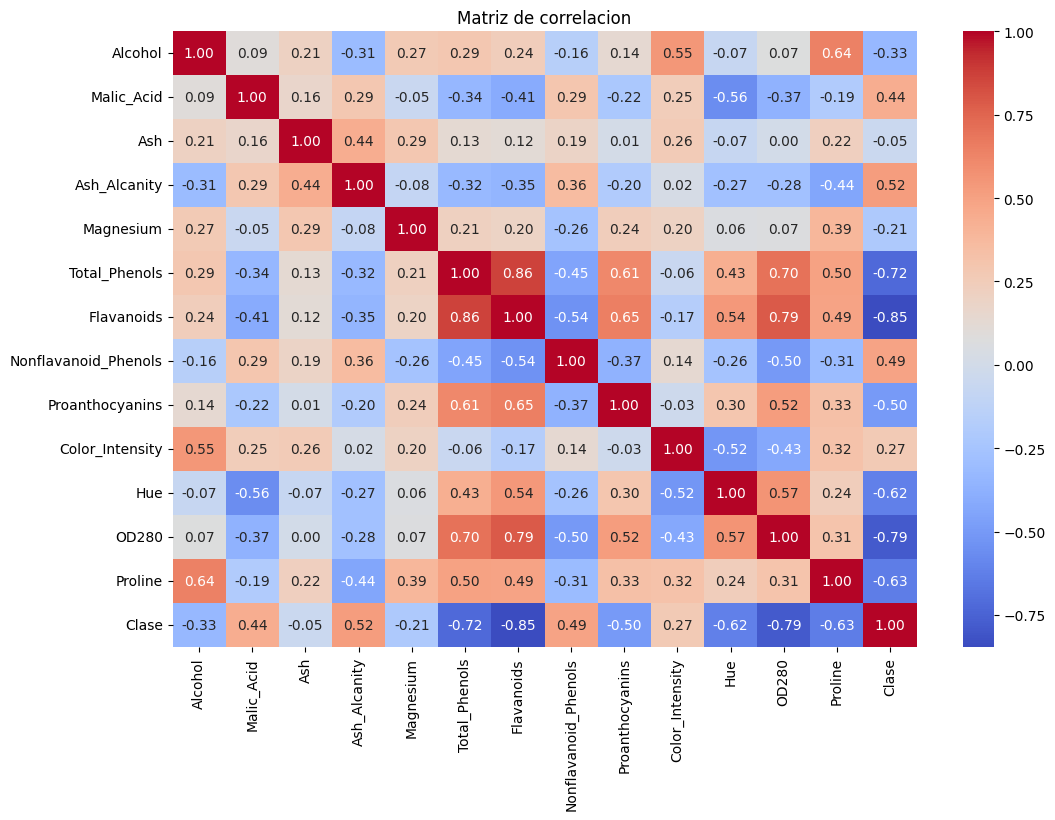

In [6]:
#verificar correlaciones
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Matriz de correlacion')
plt.show()

In [7]:
X=df.drop('Clase',axis=1)
y=df['Clase']
X

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [8]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
print(X_scaled[0])

[ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522  0.80899739
  1.03481896 -0.65956311  1.22488398  0.25171685  0.36217728  1.84791957
  1.01300893]


In [9]:
#division de la data
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)
print(X_train.shape,' ' ,X_test.shape) 

(142, 13)   (36, 13)


In [10]:
#construccion de modelos (bagging vs boosting)

#A) Bagging:Random Forest
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(X_train,y_train)
rf_pred=rf_model.predict(X_test)

In [11]:
#B) Boosting:Gradient Boosting
gb_model=GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train,y_train)
gb_pred=gb_model.predict(X_test)

In [12]:
print(f'Accuracy Random Forest entrenamiento: {accuracy_score(y_train,rf_model.predict(X_train)):.4f}')
print(f'Accuracy Random Forest test: {accuracy_score(y_test,rf_pred):.4f}')
print('-------------------------------------------------------')
print(f'Accuracy Gradient Boosting train: {accuracy_score(y_train,gb_model.predict(X_train)):.4f}')
print(f'Accuracy Gradient Boosting test: {accuracy_score(y_test,gb_pred):.4f}')


Accuracy Random Forest entrenamiento: 1.0000
Accuracy Random Forest test: 1.0000
-------------------------------------------------------
Accuracy Gradient Boosting train: 1.0000
Accuracy Gradient Boosting test: 0.9444


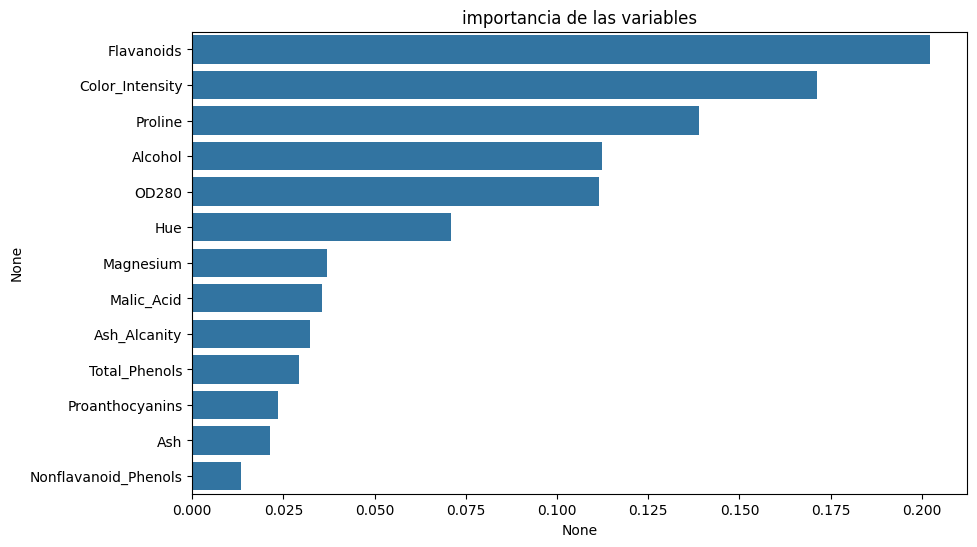

In [13]:
#importancia de las variables predictoras en random forest
importances=pd.Series(rf_model.feature_importances_,index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importances,y=importances.index)
plt.title('importancia de las variables')
plt.show()

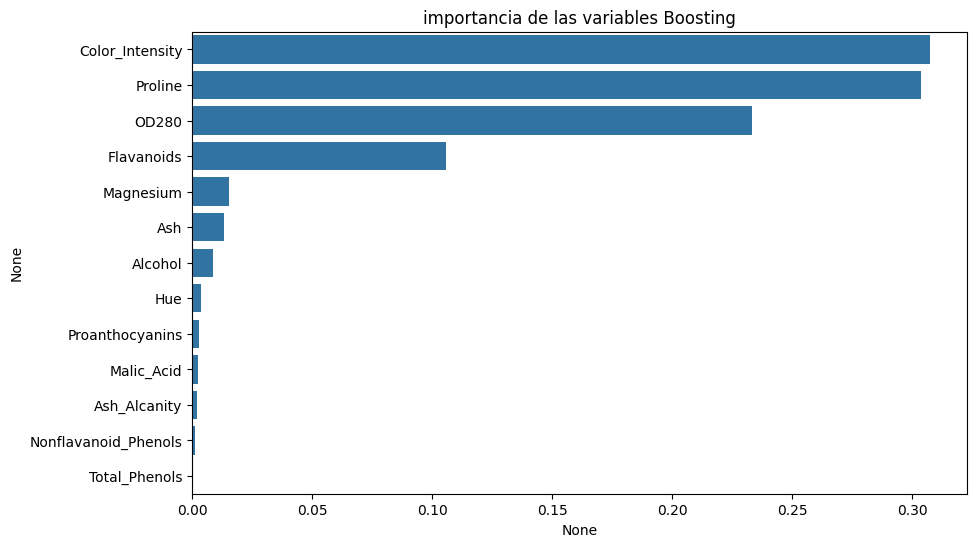

In [14]:
importances_boosting = pd.Series(gb_model.feature_importances_,index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importances_boosting,y=importances_boosting.index)
plt.title('importancia de las variables Boosting')
plt.show()

In [14]:
#hiperparametrizacion para el Gradient boosting
param_grid={
    'n_estimators':[50,100,150],
    'learning_rate':[0.01,0.1,0,2],
    'max_depth':[3,4,5],
    'subsample':[0.8,1.0]
}

grid_search=GridSearchCV(GradientBoostingClassifier(random_state=42),param_grid,cv=5,scoring='accuracy')
#evalua este modelo con estos parametros, haciendo 5 validaciones cruzadas, midiendo el accuracy
grid_search.fit(X_train,y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 4, ...], 'n_estimators': [50, 100, ...], 'subsample': [0.8, 1.0]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'



Mejores Hiperparametros: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 150, 'subsample': 0.8}

--- Reporte de Clasificacion Final ---
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



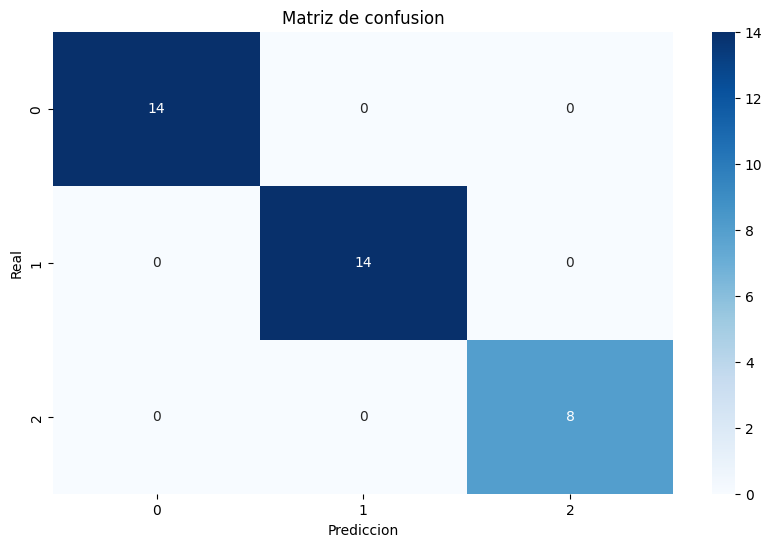

In [15]:
#mejores parametros del grid_searchCV
best_model=grid_search.best_params_
print(f'\nMejores Hiperparametros: {best_model}')

#evaluacion final
final_pred=grid_search.predict(X_test)
print('\n--- Reporte de Clasificacion Final ---')
print(classification_report(y_test,final_pred))


#matriz de confusion
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test,final_pred),annot=True,cmap='Blues',fmt='g')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.title('Matriz de confusion')
plt.show()

In [15]:
#B.2) gradient boosting
gb_model_2=GradientBoostingClassifier(random_state=42,learning_rate=0.1,max_depth=4,n_estimators=150,subsample=0.8)
gb_model_2.fit(X_train,y_train)
gb_pred_2=gb_model_2.predict(X_test)

In [16]:
print(f'Accuracy Gradient Boosting train: {accuracy_score(y_train,gb_model.predict(X_train)):.4f}')
print(f'Accuracy Gradient Boosting test: {accuracy_score(y_test,gb_pred):.4f}')
print('-------------------------------------------------------')
print(f'Accuracy Gradient Boosting train mejores parametros: {accuracy_score(y_train,gb_model_2.predict(X_train)):.4f}')
print(f'Accuracy Gradient Boosting test mejores parametros: {accuracy_score(y_test,gb_pred_2):.4f}')

Accuracy Gradient Boosting train: 1.0000
Accuracy Gradient Boosting test: 0.9444
-------------------------------------------------------
Accuracy Gradient Boosting train mejores parametros: 1.0000
Accuracy Gradient Boosting test mejores parametros: 1.0000


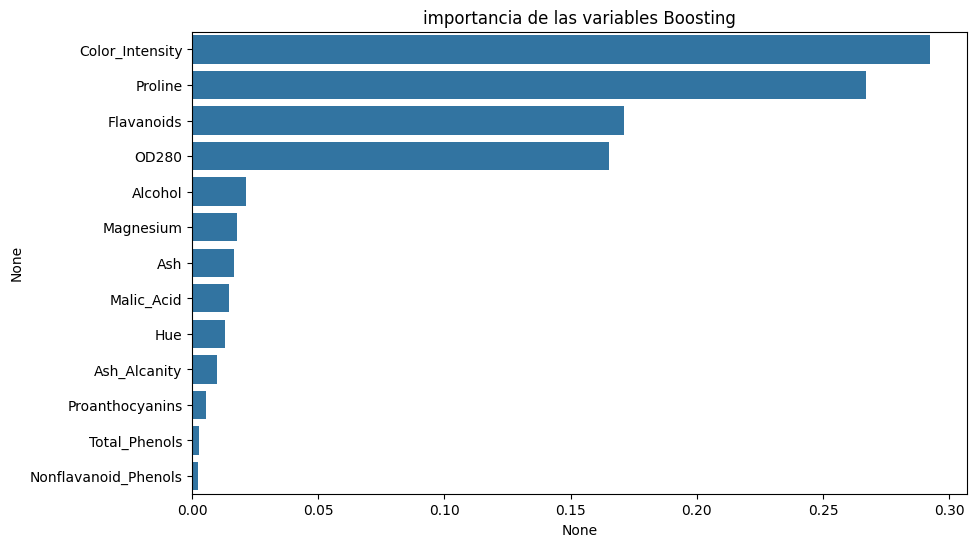

In [ ]:
#importancia mejores parametros encontrados con GrindSearchCv
importances_boosting_2 = pd.Series(gb_model_2.feature_importances_,index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importances_boosting_2,y=importances_boosting_2.index)
plt.title('importancia de las variables Boosting')
plt.show()

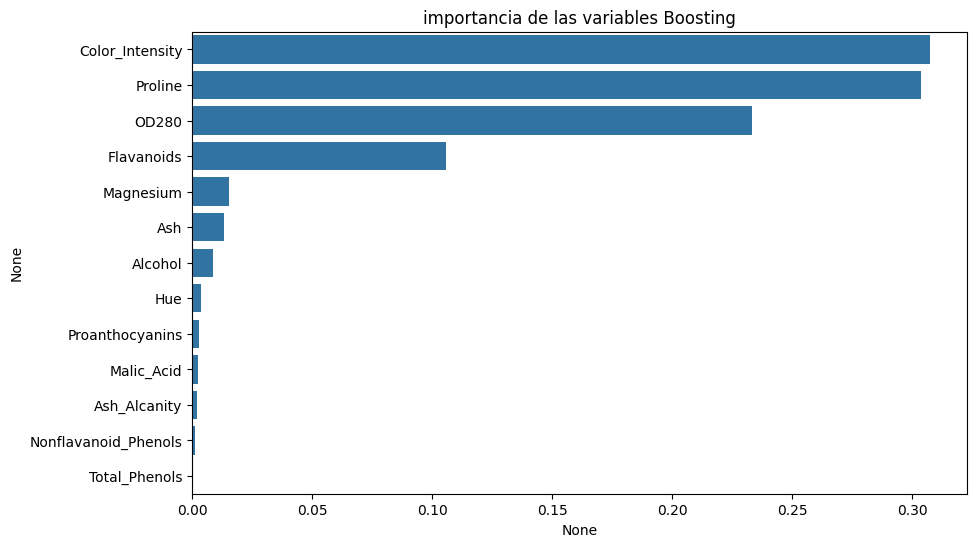

In [ ]:
#importancia variables vistas antes (sin gridsearchcv)
importances_boosting = pd.Series(gb_model.feature_importances_,index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importances_boosting,y=importances_boosting.index)
plt.title('importancia de las variables Boosting')
plt.show()